# BioDYM Material Flow Analysis - Scientific Notebook

A streamlined notebook for Material Flow Analysis using the BioDYM framework with enhanced plotting capabilities. 

## Workflow Overview

This notebook follows a structured approach to Material Flow Analysis:

1. **Setup and Data Loading** - Prepare environment and load input data
2. **Calculation & Validation** - Execute MFA analysis and verify results
3. **Visualization** - Comprehensive analysis and exploration
4. **Scenario & Uncertainty Manager** - (Optional) Compare scenarios and run Monte Carlo analysis
5. **Data Export** - Save results and generate documentation

---

# 1. Setup and Data Loading

This section prepares the analysis environment and loads the input data.

## 1.1 Environment Setup

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from IPython.display import display, HTML, Markdown
import copy

In [2]:
# Add BioDYM modules to path
src_path = os.path.join(os.getcwd(), '02_src')
sys.path.insert(0, src_path)

In [3]:
# Add ODYM framework to path
project_root = os.getcwd()
odym_path = os.path.join(
    project_root, "06_framework", "ODYM-master_20241127", "odym", "modules"
)
sys.path.insert(0, odym_path)

In [4]:
# Add bioDYM add-on to path
biodym_addon_path = os.path.join(
    project_root, "06_framework", "bioDYM_add-on", "modules"
)
sys.path.insert(0, biodym_addon_path)

In [5]:
# Import BioDYM modules
try:
    import config
    import data_loader
    import system_setup
    import utils
    from engine import solver
    import plotting
    import ODYM_Classes as msc
    from plotting.composition import plot_flow_composition
    from reporting import kpi_dashboard
    print("✅ BioDYM modules imported successfully")
except ImportError as e:
    print(f"❌ Import error: {e}")
    print("   Current Python path:")
    for i, path in enumerate(sys.path[:5]):  # Show first 5 paths
        print(f"   {i}: {path}")
    raise

✅ BioDYM modules imported successfully


In [6]:
# Set up plotting
plt.style.use('default')
print("📊 Plotting environment ready")

📊 Plotting environment ready


## 1.2 Data Input Configuration

In [7]:
# This is the only manual path setting required.
input_file = "01_data/01_input/251027_Biodym_ODYM.xlsm"
print(f"📁 Input file: {input_file}")
if not os.path.exists(input_file):
    raise FileNotFoundError(f"Input file not found: {input_file}")

📁 Input file: 01_data/01_input/251027_Biodym_ODYM.xlsm


## 1.3 System Configuration Extraction

In [8]:
print("\n" + "="*60)
print("⚙️ EXTRACTING CONFIGURATION FROM EXCEL")
print("="*60)


⚙️ EXTRACTING CONFIGURATION FROM EXCEL


In [9]:
# Load the full dataset once. This will be passed to functions that need it.
input_data = pd.read_excel(
    input_file, sheet_name=None, header=0, engine='openpyxl', na_values=['N.A.', 'NA', 'n/a'], decimal=',')
print(f"✅ Excel file loaded: {len(input_data)} sheets")

c:\Users\Johannes\anaconda3\envs\biodym_env\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)
c:\Users\Johannes\anaconda3\envs\biodym_env\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)
c:\Users\Johannes\anaconda3\envs\biodym_env\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)
c:\Users\Johannes\anaconda3\envs\biodym_env\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)
c:\Users\Johannes\anaconda3\envs\biodym_env\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)


✅ Excel file loaded: 21 sheets


c:\Users\Johannes\anaconda3\envs\biodym_env\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)
c:\Users\Johannes\anaconda3\envs\biodym_env\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)
c:\Users\Johannes\anaconda3\envs\biodym_env\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)
c:\Users\Johannes\anaconda3\envs\biodym_env\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)
c:\Users\Johannes\anaconda3\envs\biodym_env\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)
c:\Users\Johannes\anaconda3\envs\biodym_env\Lib\site-packages\openpyxl\work

In [10]:
# Use the robust loader from the config module. This function handles all errors
# and fallbacks, guaranteeing a valid config object is returned.
config_obj = config.load_configuration(input_file)
print("✅ Configuration object loaded.")

✅ Found configuration sheet: '0_Configuration'
✅ Loaded 4 elements from configuration: ['material', 'WC', 'DM', 'CC']
✅ Loaded 1 regions from configuration: ['Case_Study_Region']
✅ Loaded 4 goods from configuration: ['Raw Material', 'Processed Product', 'Product', 'Waste']
✅ Loaded 4 process types from configuration: ['Biomass Production', 'Biomass Processing', 'Use-Phase', 'EoL-Phase']
✅ Configuration object loaded.


c:\Users\Johannes\anaconda3\envs\biodym_env\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)


In [11]:
# Phase 1b: Extract dimension lists from config
def get_config_list(config_obj, attribute_name, default=None):
    """Helper to extract comma-separated lists from config object."""
    if hasattr(config_obj, attribute_name):
        value = getattr(config_obj, attribute_name)
        if value and pd.notna(value):
            return [item.strip() for item in str(value).split(',') if item.strip()]
    return default

In [12]:
regions = get_config_list(config_obj, 'Regions', ['Case_Study_Region'])
goods = get_config_list(config_obj, 'Goods', None)
materials = get_config_list(config_obj, 'Materials', None)
processes = get_config_list(config_obj, 'Process_Types', None)

In [13]:
print(f"📊 Dimensions loaded from configuration:")
print(f"   - Regions: {regions}")
if materials:
    print(f"   - Materials: {materials}")
if goods:
    print(f"   - Goods: {goods}")
if processes:
    print(f"   - Process Types: {processes}")

📊 Dimensions loaded from configuration:
   - Regions: ['Case_Study_Region']
   - Goods: ['Raw Material', 'Processed Product', 'Product', 'Waste']
   - Process Types: ['Biomass Production', 'Biomass Processing', 'Use-Phase', 'EoL-Phase']


In [14]:
# Extract core values from the config object, with fallbacks to data-driven values
try:
    start_year = int(config_obj.Start_Year)
    end_year = int(config_obj.End_Year)
    # Try different possible element attribute names
    if hasattr(config_obj, 'Elements'):
        elements = [elem.strip() for elem in config_obj.Elements.split(',')]
    elif hasattr(config_obj, 'Elements_comma_separated'):
        elements = [elem.strip() for elem in config_obj.Elements_comma_separated.split(',')]
    elif hasattr(config_obj, 'Element_list'):
        elements = [elem.strip() for elem in config_obj.Element_list.split(',')]
    else:
        raise AttributeError("No Elements attribute found in config object")
except Exception as e:
    print(f"⚠️ Could not get time/elements from config object: {e}. Falling back to data-driven values.")
    flow_data = input_data['1_2_Data_Flows']
    # Fix: Use correct column name 'Flow_Data_Year' instead of 'Year_Flow'
    years = sorted(flow_data['Flow_Data_Year'].unique())
    start_year = int(min(years))
    end_year = int(max(years))
    elements = ['material', 'WC', 'DM', 'CC']

In [15]:
# Display final configuration summary
run_scenario = getattr(config_obj, 'Run_Scenario_Analysis', False)
selected_scenario = getattr(config_obj, 'Selected_Scenario_Name 1', getattr(config_obj, 'Selected_Scenario_Name', 'N/A'))

In [16]:
print(f"\n-- Configuration Summary --")
print(f"📅 Time range: {start_year} - {end_year}")
print(f"🧪 Elements: {elements}")
print(f"🎲 Monte Carlo: {'Enabled' if config_obj.RUN_MONTE_CARLO else 'Disabled'}")
print(f"📊 DSM Calculation: {'Enabled' if config_obj.RUN_DSM_CALCULATION else 'Disabled'}")
print(f"🌱 FOMP Calculation: {'Enabled' if config_obj.RUN_FOMP_CALCULATION else 'Disabled'}")
print(f"🎭 Scenario Analysis: {'Enabled' if run_scenario else 'Disabled'}")
if run_scenario:
    print(f"   -> Selected Scenario: '{selected_scenario}'")


-- Configuration Summary --
📅 Time range: 2025 - 2050
🧪 Elements: ['material', 'WC', 'DM', 'CC']
🎲 Monte Carlo: Disabled
📊 DSM Calculation: Enabled
🌱 FOMP Calculation: Enabled
🎭 Scenario Analysis: Disabled


# 2. Calculation and Validation

In [17]:
# ## 2.1 Model Initialization & Calculation
print("\n" + "="*60)
print("🚀 RUNNING BASELINE MFA CALCULATION")
print("="*60)


🚀 RUNNING BASELINE MFA CALCULATION


In [18]:
print("📋 Setting up model scope...")
model_classification, index_table = system_setup.define_model_scope(start_year, end_year, elements, regions, goods, materials, processes)

📋 Setting up model scope...
--> Model scope and classifications defined with 2 dimensions.


In [19]:
print("🔧 Initializing MFA system...")
mfa_system_base = system_setup.initialize_mfa_system(model_classification, index_table)

🔧 Initializing MFA system...
--> IndexTable validation passed.
--> MFA system object initialized.


In [20]:
# Phase 1b: Display IndexTable (ODYM convention)
print("\n" + "="*60)
print("📊 ODYM SYSTEM INDEX TABLE")
print("="*60)
print(mfa_system_base.IndexTable)
print("\nAvailable Dimensions:")
for aspect in mfa_system_base.IndexTable.index:
    classification = mfa_system_base.IndexTable.loc[aspect, 'Classification']
    index_letter = mfa_system_base.IndexTable.loc[aspect, 'IndexLetter']
    print(f"  - {aspect} ({index_letter}): {len(classification.Items)} items")
    if len(classification.Items) <= 5:
        print(f"    Items: {classification.Items}")
    else:
        print(f"    Items (sample): {classification.Items[:3]} ... ({len(classification.Items)} total)")


📊 ODYM SYSTEM INDEX TABLE
                    Description Dimension  \
Aspect                                      
Time        Model aspect "time"      Time   
Element  Model aspect "Element"   Element   

                                            Classification IndexLetter  
Aspect                                                                  
Time     <ODYM_Classes.Classification object at 0x00000...           t  
Element  <ODYM_Classes.Classification object at 0x00000...           e  

Available Dimensions:
  - Time (t): 26 items
    Items (sample): [np.int64(2025), np.int64(2026), np.int64(2027)] ... (26 total)
  - Element (e): 4 items
    Items: ['material', 'WC', 'DM', 'CC']


In [21]:
print("📊 Loading processes and data...")
mfa_system_base, all_excel_data = system_setup.load_and_define_processes(mfa_system_base, input_data, data_loader)

📊 Loading processes and data...
--> Defining process and stock structures...
--> Validating input data structure...
  -> Using unified configuration columns in '2_1_Definition_Processes'
--> Input data validation successful.
--> Stock values initialized.


In [22]:
print("🔗 Defining flows and base parameters (e.g., compositions from flowsheet)...")
mfa_system_configured, _, flow_tc_map, process_logic_map = system_setup.define_flows_and_parameters(mfa_system_base, all_excel_data)

🔗 Defining flows and base parameters (e.g., compositions from flowsheet)...
--> Defining flows, parameters, and setting all initial values...
--> All flows initialized to zero.
--> Populated data for primary input flows.
--> Loading initial stock parameters from sheet '2_4_Initial_Stock'...
--> Successfully loaded initial stock configurations for 0 process(es).
--> Parameter values initialized successfully.
--> Creating Flow-to-TC mapping...
--> Consistency check passed.


In [23]:
print("⚙️ Loading all model parameters (TCs, DSM, FOMP)...")

⚙️ Loading all model parameters (TCs, DSM, FOMP)...


In [24]:
# Centralized call to the new, unified TC loader
time_vector = mfa_system_configured.IndexTable.Classification['Time'].Items
elements_list = mfa_system_configured.Elements
tc_params = data_loader.load_tc_parameters(all_excel_data, elements_list, time_vector)
mfa_system_configured.ParameterDict.update(tc_params) # Add the new TC params to the system

--> Loading Transfer Coefficients using unified TC_Configuration...
--> INFO: Process 0 (Pass-through) - skipping TCs (process type)
--> INFO: Process 1 (Pass-through) - skipping TCs (process type)
  -> Processing static TCs for 20 processes...
    -> Loaded static TC: TC_material_02_03 = 1.0
    -> Loaded static TC: TC_material_03_04 = 0.474
    -> Loaded static TC: TC_material_03_09 = 0.0738503999999999
    -> Loaded static TC: TC_material_03_05 = 0.38924
    -> Loaded static TC: TC_material_03_06 = 0.0629096
    -> Loaded static TC: TC_material_04_01 = 0.4128
    -> Loaded static TC: TC_WC_04_01 = 0.0
    -> Loaded static TC: TC_DM_04_01 = 0.48
    -> Loaded static TC: TC_CC_04_01 = 1.0
    -> Loaded static TC: TC_material_04_00 = 0.5872
    -> Loaded static TC: TC_WC_04_00 = 1.0
    -> Loaded static TC: TC_DM_04_00 = 0.52
    -> Loaded static TC: TC_CC_04_00 = 0.0
    -> Loaded static TC: TC_material_06_01 = 0.4128
    -> Loaded static TC: TC_WC_06_01 = 0.0
    -> Loaded static TC:

In [25]:
# Load other special model parameters
dsm_params = data_loader.load_dsm_parameters(all_excel_data)
if config_obj.RUN_FOMP_CALCULATION:
    fomp_params = data_loader.load_fomp_parameters(all_excel_data)
else:
    fomp_params = {}
uncertainty_params = data_loader.load_uncertainty_definitions(all_excel_data)

--> Loading DSM parameters from sheet '3_1_Definition_DSM'...
--> Using Process_Logic column from main sheet to identify DSM processes: [15]
--> Successfully loaded configurations for 1 DSM process(es).
--> Loading FOMP parameters from sheet '3_2_Definition_FOMP'...
--> Successfully loaded configurations for 3 FOMP process(es).
   Process 5: 6 parameters
   Process 22: 6 parameters
   Process 23: 1 parameters
--> Loading uncertainty definitions from sheet '4_1_Uncertainty_Parameters'...
  DEBUG: df_uncertainty before dropna:
    ID  MC_Parameter  Parameter_Selection  Parameter_Name  Distribution_Type  \
0    1           NaN                  NaN             NaN                NaN   
1    2           NaN                  NaN             NaN                NaN   
2    3           NaN                  NaN             NaN                NaN   
3    4           NaN                  NaN             NaN                NaN   
4    5           NaN                  NaN             NaN            

In [26]:
print("✅ All parameters loaded and configured.")

✅ All parameters loaded and configured.


In [27]:
print("🧮 Running baseline calculation...")
mfa_results_baseline, dsm_details_baseline = solver.run_mfa_calculation(mfa_system_configured, dsm_params, fomp_params, config_obj, flow_tc_map=flow_tc_map, process_logic_map=process_logic_map)
print("✅ Baseline calculation completed successfully!")

🧮 Running baseline calculation...
[DSM DEBUG] Iteration 0: Process 15, Inflows: ['F_11_15'], Total Inflow Sum: 1735405.00, Ready: True
=== DSM DEBUG for Process 15 ===

--- Processing Category 1 (Packaging Material of consumer goods ) ---
Inflow category 1: [21891.84732622 18450.32484298 22710.13391229 27454.42655338
 17930.71822311]... (first 5 years)

--- Processing Category 2 (Panel board ) ---
Inflow category 2: [7297.28244207 6150.10828099 7570.04463743 9151.47551779 5976.90607437]... (first 5 years)

--- Processing Category 3 (Thermal insulation material,
Construction materials ) ---
Inflow category 3: [7297.28244207 6150.10828099 7570.04463743 9151.47551779 5976.90607437]... (first 5 years)

--- Initial Stock Processing ---

--- Final Results Summary ---
Total outflow from inflows: 677780.2826244546
Total outflow from initial stock: 0.0
Total outflow material: 677780.2826244547
Total stock accumulated from inflows: 2844213.2326868023
=== END DSM DEBUG for Process 15 ===

✅ DSM v

c:\Users\Johannes\anaconda3\envs\biodym_env\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\Johannes\anaconda3\envs\biodym_env\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


## 2.2 Mass Balance Validation

In [28]:
print("\n" + "="*60)
print("⚖️ MASS BALANCE VERIFICATION (BASELINE)")
print("="*60)
plotting.plot_total_mass_balance_error(mfa_results_baseline)
plotting.plot_optimized_mass_balance_error(mfa_results_baseline)


⚖️ MASS BALANCE VERIFICATION (BASELINE)


interactive(children=(IntSlider(value=2025, description='Year', max=2050, min=2025), Dropdown(description='Ele…

FigureWidget({
    'data': [{'hovertemplate': '<b>%{x}</b><br>Error: %{y:.2e} Mg<extra></extra>',
              'marker': {'color': [#00C851, #00C851, #00C851, #00C851, #00C851,
                                   #00C851, #00C851, #00C851, #00C851, #00C851,
                                   #00C851, #00C851, #00C851, #00C851, #00C851,
                                   #00C851, #00C851, #00C851, #00C851, #00C851,
                                   #00C851, #00C851, #00C851],
                         'line': {'color': '#212529', 'width': 1}},
              'type': 'bar',
              'uid': '99821c20-cda7-4a85-80ac-b240b361b70b',
              'x': [Environment, Atmosphere, Rye_Cultivation, Rye_Harvest, Rye-
                    Grain_Processing & Consumption, Rye-Straw(non-
                    mobilizable)_Degradation, Rye-Straw-mobilisable technical
                    potential_Use, Biogas_Incineration, Biogas_Production-Delta,
                    Biogas_Production, Cow-Manure_Produ


--- System Flow Diagram (Graphviz) ---
🔍 Graphviz Analysis:
   Input: 46 processes, 95 flows
   Data Quality Check:
   - Complete processes: 23/46
   - Complete flows: 51/95
   - Connected processes: 21
   ⚠️ Too many processes (21 > 20)
   📊 Selecting most connected processes...
   ✅ Selected 20 most connected processes
   ⚠️ Too many flows (49 > 30)
   📊 Selecting most important flows...
   ✅ Selected 30 flows
   Final: 20 processes, 30 flows
   ✅ Graphviz chart created successfully!


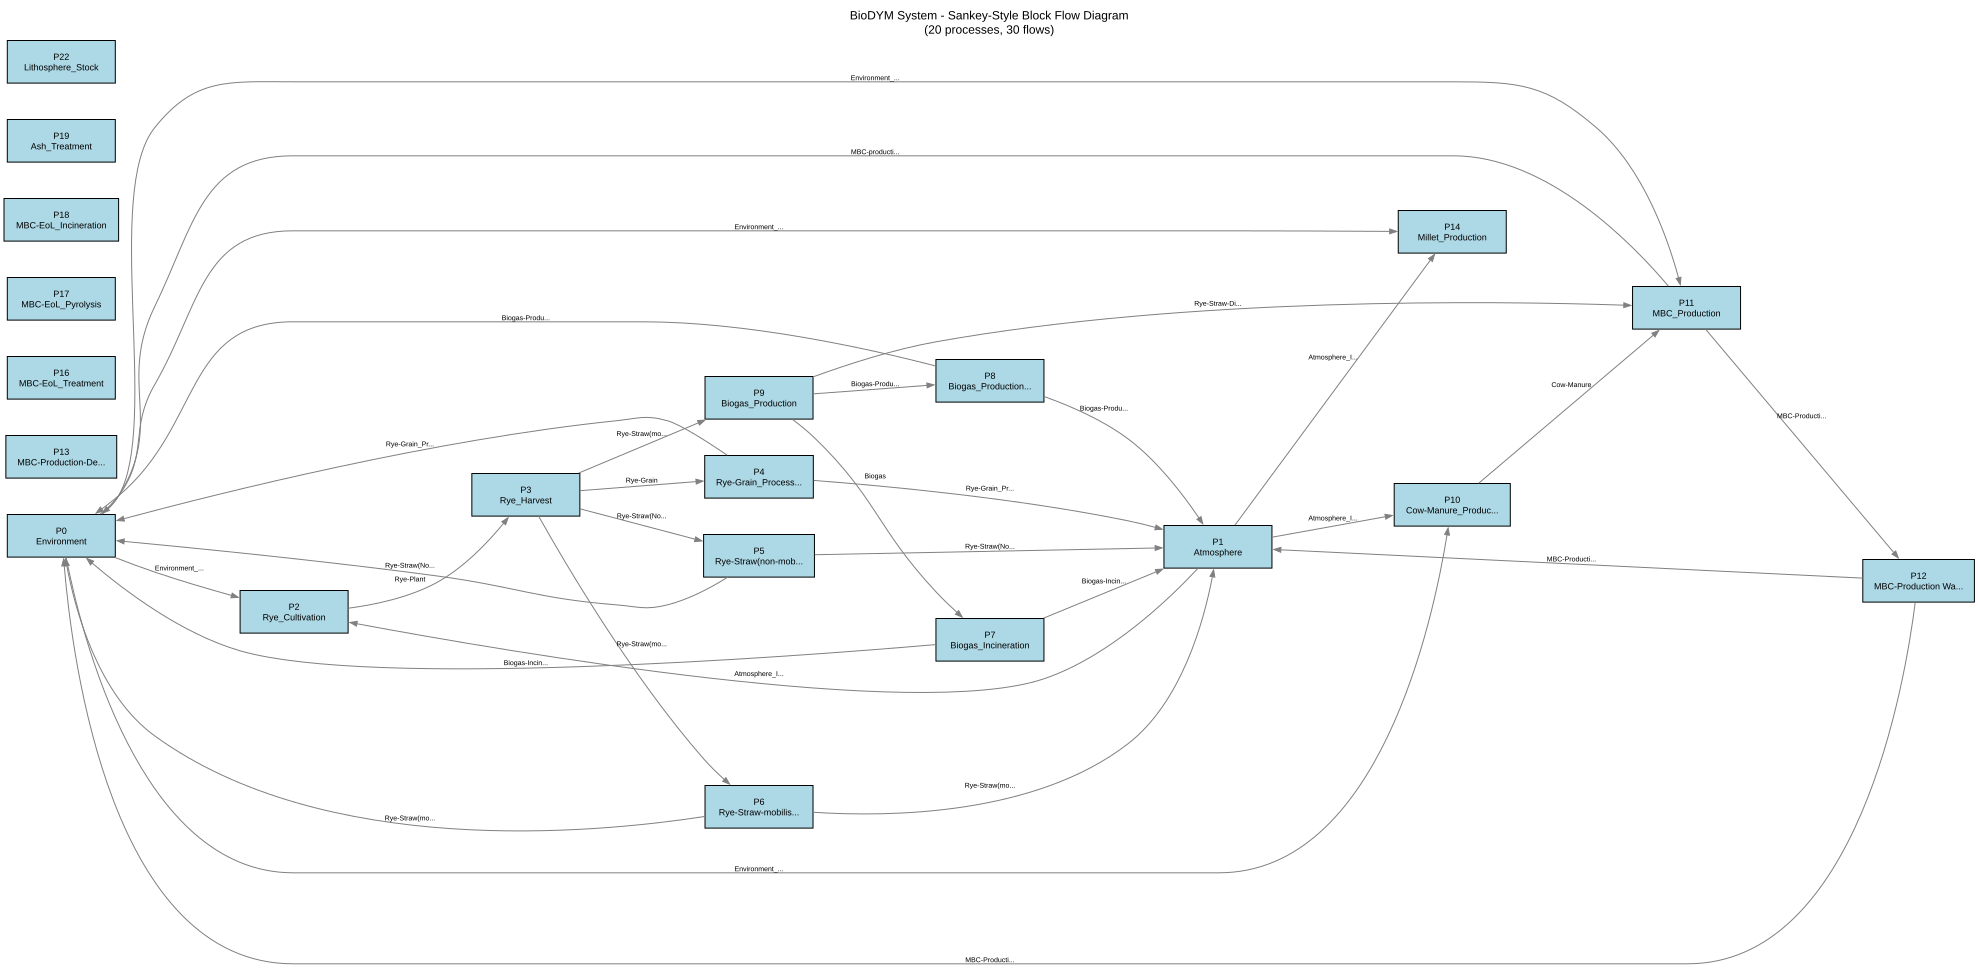

✅ Graphviz chart created successfully!


In [29]:
# ## 2.3 System Flow Diagram (Graphviz)
print("\n--- System Flow Diagram (Graphviz) ---")
try:
    from plotting.graphviz_flow_charts import plot_graphviz_flow_chart_sankey_style
    
    # Get the required dataframes from the loaded data
    processes_data = all_excel_data['2_1_Definition_Processes']
    flows_data = all_excel_data['1_1_Definition_Flows']
    
    # Generate and display the chart
    dot_chart = plot_graphviz_flow_chart_sankey_style(processes_data, flows_data)
    if dot_chart:
        display(dot_chart)
        print("✅ Graphviz chart created successfully!")
except ImportError:
    print("⚠️ Graphviz library not found. Skipping this plot.")
except Exception as e:
    print(f"⚠️ Graphviz chart failed: {e}")

# 3. Visualization

In [30]:
print("\n" + "="*60)
print("📊 VISUALIZATION (BASELINE)")
print("="*60)


📊 VISUALIZATION (BASELINE)


In [31]:
# ## 3.1 Traditional Sankey Diagram
print("\n--- Traditional Sankey Diagram ---")
plotting.plot_interactive_sankey(mfa_results_baseline, dsm_params, fomp_params)


--- Traditional Sankey Diagram ---


FigureWidget({
    'data': [{'arrangement': 'snap',
              'link': {'color': [#00C851, #00C851, #00C851, #00C851, #00C851,
                                 #00C851, #00C851, #00C851, #00C851, #00C851,
                                 #00C851, #00C851, #00C851, #00C851, #00C851,
                                 #00C851, #00C851, #00C851, #00C851, #00C851,
                                 #00C851, #00C851, #00C851, #00C851, #00C851,
                                 #00C851, #00C851, #00C851, #00C851, #00C851,
                                 #00C851, #00C851, #00C851, #00C851, #00C851,
                                 #00C851, #00C851, #00C851, #00C851, #00C851,
                                 #00C851, #00C851, #00C851, #00C851, #00C851,
                                 #00C851, #00C851, #00C851],
                       'customdata': [F_01_02, F_00_02, F_01_10, F_00_10, F_01_14,
                                      F_00_14, F_00_11, F_02_03, F_03_04, F_04_01,
                   

In [32]:
# ## 3.2 Enhanced Sankey Diagram
print("\n--- Enhanced Sankey Diagram ---")
try:
    from plotting.enhanced_sankey import plot_enhanced_sankey
    print("🎯 Creating enhanced Sankey diagram...")
    plot_enhanced_sankey(
        mfa_system_results=mfa_results_baseline,
        dsm_params=dsm_params,
        fomp_params=fomp_params,
        visualization_config_path=input_file
    )
    print("✅ Enhanced Sankey diagram created successfully!")
except Exception as e:
    print(f"⚠️ Enhanced Sankey diagram failed: {e}")
    import traceback
    traceback.print_exc()


--- Enhanced Sankey Diagram ---
🎯 Creating enhanced Sankey diagram...
Loading visualization configuration from Excel...
  Loaded and processed 6_1_Visualization_Processes
  Loaded 6_2_Visualization_Flows
  Loaded 6_3_Layout_Configuration
Visualization configuration loaded successfully


⚠️ Enhanced Sankey diagram failed: 
    Invalid element(s) received for the 'color' property of sankey.node
        Invalid elements include: [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]

    The 'color' property is a color and may be specified as:
      - A hex string (e.g. '#ff0000')
      - An rgb/rgba string (e.g. 'rgb(255,0,0)')
      - An hsl/hsla string (e.g. 'hsl(0,100%,50%)')
      - An hsv/hsva string (e.g. 'hsv(0,100%,100%)')
      - A named CSS color: see https://plotly.com/python/css-colors/ for a list
      - A list or array of any of the above


Traceback (most recent call last):
  File "C:\Users\Johannes\AppData\Local\Temp\ipykernel_17292\1577506289.py", line 6, in <module>
    plot_enhanced_sankey(
    ~~~~~~~~~~~~~~~~~~~~^
        mfa_system_results=mfa_results_baseline,
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    ...<2 lines>...
        visualization_config_path=input_file
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "c:\Users\Johannes\Nextcloud\BioDYM\bioDYM-CERT-edit-main\02_src\plotting\enhanced_sankey.py", line 414, in plot_enhanced_sankey
    handle_change(None) # Initial plot draw
    ~~~~~~~~~~~~~^^^^^^
  File "c:\Users\Johannes\Nextcloud\BioDYM\bioDYM-CERT-edit-main\02_src\plotting\enhanced_sankey.py", line 405, in handle_change
    update_sankey(year_slider.value, element_dropdown.value, process_selector.value, min_flow_slider.value, layout_dropdown.value)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
 

In [33]:
# ## 3.3 Additional Visualizations
print("\n--- Additional Visualizations ---")


--- Additional Visualizations ---


In [34]:
# ### 3.3.1 Core System Dynamics
print("\n📊 Core System Dynamics:")
print("   • Process Dynamics: Interactive 3-panel view (Inflow/Stock/Outflow)")
print("   • Flow Dynamics: Multi-flow time series analysis")
print("   • Stock Analysis: Interactive bar charts with time slider")


📊 Core System Dynamics:
   • Process Dynamics: Interactive 3-panel view (Inflow/Stock/Outflow)
   • Flow Dynamics: Multi-flow time series analysis
   • Stock Analysis: Interactive bar charts with time slider


In [35]:
# Process Dynamics - 3-panel view showing inflow, stock, and outflow for selected processes
print("\n🔄 Process Dynamics Analysis:")
plotting.plot_process_dynamics(mfa_results_baseline, all_excel_data['2_1_Definition_Processes'])


🔄 Process Dynamics Analysis:


interactive(children=(Dropdown(description='Process:', options=('Environment', 'Atmosphere', 'Rye_Cultivation'…

FigureWidget({
    'data': [{'mode': 'lines',
              'name': 'Inflow',
              'type': 'scatter',
              'uid': 'e00f2173-68d5-4c22-b378-3e943d054b68',
              'x': [2025, 2026, 2027, 2028, 2029, 2030, 2031, 2032, 2033, 2034,
                    2035, 2036, 2037, 2038, 2039, 2040, 2041, 2042, 2043, 2044,
                    2045, 2046, 2047, 2048, 2049, 2050],
              'xaxis': 'x',
              'y': {'bdata': ('yK/0r4JQIEHpGbGirnAfQRSSTevC3S' ... 'S0fRtBJVvDc2WiIEFeLMaYxkojQQ=='),
                    'dtype': 'f8'},
              'yaxis': 'y'},
             {'mode': 'lines',
              'name': 'Stock',
              'type': 'scatter',
              'uid': 'dd6d5d31-7e9f-42ca-9974-f0d4a2be803b',
              'x': [2025, 2026, 2027, 2028, 2029, 2030, 2031, 2032, 2033, 2034,
                    2035, 2036, 2037, 2038, 2039, 2040, 2041, 2042, 2043, 2044,
                    2045, 2046, 2047, 2048, 2049, 2050],
              'xaxis': 'x2',
              

In [36]:
# Flow Dynamics - Multi-flow time series with element selection
print("\n🌊 Flow Dynamics Analysis:")
plotting.plot_flow_dynamics(mfa_results_baseline)


🌊 Flow Dynamics Analysis:


interactive(children=(SelectMultiple(description='Flows:', index=(0,), options=('F_00_02', 'F_00_10', 'F_00_11…

FigureWidget({
    'data': [{'mode': 'lines',
              'name': 'F_00_02',
              'type': 'scatter',
              'uid': 'e1612856-af0f-414d-b68e-1ea0a40be851',
              'x': [2025, 2026, 2027, 2028, 2029, 2030, 2031, 2032, 2033, 2034,
                    2035, 2036, 2037, 2038, 2039, 2040, 2041, 2042, 2043, 2044,
                    2045, 2046, 2047, 2048, 2049, 2050],
              'y': {'bdata': ('35BAjwmQJUH21UmVQSwiQWQe6lxeXi' ... 'g6nBZBx12WizcBIEE+UlOtyIAjQQ=='),
                    'dtype': 'f8'}}],
    'layout': {'barmode': 'overlay',
               'font': {'color': '#212529', 'family': 'Arial, sans-serif', 'size': 10},
               'height': 800,
               'legend': {'bgcolor': 'rgba(255,255,255,0.8)',
                          'bordercolor': '#6C757D',
                          'borderwidth': 1,
                          'font': {'color': '#212529', 'family': 'Arial, sans-serif', 'size': 10}},
               'margin': {'b': 100, 'l': 100, 'r': 50, 't

In [37]:
# Stock Bar Chart - Interactive stock levels with time slider
print("\n📈 Stock Levels Analysis:")
plotting.plot_stock_bar_chart(mfa_results_baseline, title="Stock Levels Over Time (Baseline)")


📈 Stock Levels Analysis:


interactive(children=(IntSlider(value=2025, description='Year', max=2050, min=2025), Dropdown(description='Ele…

FigureWidget({
    'data': [{'hovertemplate': '<b>%{x}</b><br>Stock: %{y:.2f} Mg<extra></extra>',
              'marker': {'color': ['#2ca02c', '#2ca02c', '#2ca02c', '#2ca02c', '#2ca02c']},
              'type': 'bar',
              'uid': '46cb8723-023c-4724-b0e6-ec41d5c023ef',
              'x': array(['Environment', 'Atmosphere', 'Rye-Straw(non-mobilizable)_Degradation',
                          'MBC_Use-Phase', 'Lithosphere_Stock'], dtype=object),
              'y': {'bdata': 'AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA==', 'dtype': 'f8'}}],
    'layout': {'font': {'color': '#212529', 'family': 'Arial, sans-serif', 'size': 10},
               'height': 800,
               'legend': {'bgcolor': 'rgba(255,255,255,0.8)',
                          'bordercolor': '#6C757D',
                          'borderwidth': 1,
                          'font': {'color': '#212529', 'family': 'Arial, sans-serif', 'size': 10}},
               'margin': {'b': 100, 'l': 100, 'r': 50, 't': 

In [38]:
# System Stock Composition - Individual process stocks over time
print("\n🏗️ Individual Process Stocks Analysis:")
print("   • Individual process stocks over time")
print("   • Shows each process stock separately")
print("   • Element selection and bar/line chart options")
plotting.plot_system_stock_composition(mfa_results_baseline)


🏗️ Individual Process Stocks Analysis:
   • Individual process stocks over time
   • Shows each process stock separately
   • Element selection and bar/line chart options


FigureWidget({
    'data': [], 'layout': {'template': '...'}
})

In [39]:
# ### 3.3.2 Specialized Process Analysis (if applicable)
print("\n📊 Specialized Process Analysis:")


📊 Specialized Process Analysis:


In [40]:
# DSM Stock Details - Detailed DSM stock evolution (if DSM processes exist)
if dsm_params and dsm_details_baseline:
    print("\n🏗️ DSM Stock Evolution Analysis:")
    print("   • Individual and cumulative stock views")
    print("   • Lifetime analysis and category breakdown")
    plotting.plot_dsm_stock_details(mfa_results_baseline, dsm_params, dsm_details_baseline)
    
    print("\n🔄 DSM Process Dynamics Analysis:")
    print("   • Three-panel view: Input, Stock, Output")
    print("   • Stacked flows by element (Material, WC, DM, CC)")
    print("   • Dynamic material composition for DSM processes")
    plotting.plot_dsm_process_dynamics(mfa_results_baseline, dsm_params, dsm_details_baseline)
else:
    print("   ℹ️ No DSM processes found - skipping DSM analysis")


🏗️ DSM Stock Evolution Analysis:
   • Individual and cumulative stock views
   • Lifetime analysis and category breakdown


FigureWidget({
    'data': [{'fill': 'tozeroy',
              'hovertemplate': '<b>Initial Stock</b><br>Year: %{x}<br>Mass: %{y:.2f} Mg<extra></extra>',
              'line': {'color': '#ff7f0e', 'dash': 'dash', 'width': 0.5},
              'mode': 'lines',
              'name': 'Initial Stock (Decaying)',
              'stackgroup': 'one',
              'type': 'scatter',
              'uid': 'ed41c993-8360-48fc-ba92-f3f372669098',
              'x': [2025, 2026, 2027, 2028, 2029, 2030, 2031, 2032, 2033, 2034,
                    2035, 2036, 2037, 2038, 2039, 2040, 2041, 2042, 2043, 2044,
                    2045, 2046, 2047, 2048, 2049, 2050],
              'y': {'bdata': ('AAAAAAAAAAAAAAAAAAAAAAAAAAAAAA' ... 'AAAAAAAAAAAAAAAAAAAAAAAAAAAA=='),
                    'dtype': 'f8'}},
             {'fill': 'tonexty',
              'hovertemplate': ('<b>Packaging Material of consu' ... 'ss: %{y:.2f} Mg<extra></extra>'),
              'line': {'width': 0.5},
              'mode': 'lines',
 


🔄 DSM Process Dynamics Analysis:
   • Three-panel view: Input, Stock, Output
   • Stacked flows by element (Material, WC, DM, CC)
   • Dynamic material composition for DSM processes


FigureWidget({
    'data': [{'fill': 'tozeroy',
              'hovertemplate': '<b>F_11_15</b><br>Year: %{x}<br>material: %{y:.2e} Mg<extra></extra>',
              'line': {'width': 0.5},
              'mode': 'lines',
              'name': 'F_11_15',
              'stackgroup': 'input',
              'type': 'scatter',
              'uid': '0ed8abd3-8b65-4f34-93ad-84bd789db879',
              'x': [2025, 2026, 2027, 2028, 2029, 2030, 2031, 2032, 2033, 2034,
                    2035, 2036, 2037, 2038, 2039, 2040, 2041, 2042, 2043, 2044,
                    2045, 2046, 2047, 2048, 2049, 2050],
              'xaxis': 'x',
              'y': {'bdata': ('Y2sF1chp4kBzVZtwgAnfQLk8War6Ge' ... 'zNTtNAcBt6go9V20DKZm+UiqfgQA=='),
                    'dtype': 'f8'},
              'yaxis': 'y'},
             {'hovertemplate': '<b>S_15</b><br>Year: %{x}<br>material: %{y:.2e} Mg<extra></extra>',
              'line': {'color': '#2E8B57', 'width': 3},
              'marker': {'size': 4},
           

In [41]:
# FOMP Analysis - FOMP mineralization analysis (if FOMP processes exist)
if fomp_params:
    print("\n🌱 FOMP Mineralization Analysis:")
    print("   • Organic matter accumulation and mineralization")
    print("   • Annual vs cumulative flow analysis")
    plotting.plot_fomp_stock_details(mfa_results_baseline, fomp_params)
    
    # FOMP Process Dynamics - Three-panel view of FOMP processes
    print("\n🔄 FOMP Process Dynamics:")
    print("   • Three panels: Input Flows (DM), Stock Evolution (DM), Mineralization Output (DM)")
    print("   • Decay rates displayed as percentages")
    print("   • Water Content (WC) excluded from mineralization")
    plotting.plot_fomp_dynamics(mfa_results_baseline, fomp_params)
else:
    print("   ℹ️ No FOMP processes found - skipping FOMP analysis")


🌱 FOMP Mineralization Analysis:
   • Organic matter accumulation and mineralization
   • Annual vs cumulative flow analysis


FigureWidget({
    'data': [{'hovertemplate': '<b>Stock</b><br>Year: %{x}<br>Mass: %{y:.2f} Mg<extra></extra>',
              'line': {'color': '#2ca02c', 'width': 3},
              'marker': {'size': 4},
              'mode': 'lines+markers',
              'name': 'Organic Matter Stock',
              'type': 'scatter',
              'uid': '9792cc86-046d-4c93-af53-90ef2c970f0e',
              'x': [2025, 2026, 2027, 2028, 2029, 2030, 2031, 2032, 2033, 2034,
                    2035, 2036, 2037, 2038, 2039, 2040, 2041, 2042, 2043, 2044,
                    2045, 2046, 2047, 2048, 2049, 2050],
              'y': {'bdata': ('AAAAAAAAAACBGBvGo5UYQW9uZsToLC' ... 'TzgUJBx7ET6eznQUFWoXEZj0NCQQ=='),
                    'dtype': 'f8'}},
             {'hovertemplate': '<b>Annual Input</b><br>Year: %{x}<br>Mass: %{y:.2f}} Mg<extra></extra>',
              'line': {'color': '#1f77b4', 'dash': 'dash', 'width': 2},
              'marker': {'size': 3},
              'mode': 'lines+markers',
       


🔄 FOMP Process Dynamics:
   • Three panels: Input Flows (DM), Stock Evolution (DM), Mineralization Output (DM)
   • Decay rates displayed as percentages
   • Water Content (WC) excluded from mineralization


In [42]:
# ### 3.3.3 Flow Composition
print("\n--- Flow Composition ---")
plot_flow_composition(mfa_results_baseline)


--- Flow Composition ---


In [43]:
# Export flow composition data
from plotting.composition_export import export_flow_composition
export_path = "01_data/02_output/composition_export/flow_composition.xlsx"
export_flow_composition(mfa_results_baseline, export_path)


--> Flow composition data successfully exported to 01_data/02_output/composition_export/flow_composition.xlsx


# 4. Scenario & Uncertainty Manager

In [44]:
# ## 4.1 Scenario Analysis & Comparison
print("\n" + "="*60)
print("🎭 SCENARIO ANALYSIS")
print("="*60)


🎭 SCENARIO ANALYSIS


In [45]:
# Import the new scenario engine
from engine import scenario_engine

In [46]:
# Run scenario analysis using the new engine
all_scenario_results, scenario_definitions = scenario_engine.run_scenario_analysis(
    config_obj=config_obj,
    mfa_system_configured=mfa_system_configured,
    all_excel_data=all_excel_data,
    dsm_params=dsm_params,
    fomp_params=fomp_params,
    flow_tc_map=flow_tc_map,
    process_logic_map=process_logic_map
)


🎭 SCENARIO ANALYSIS ENGINE
ℹ️ Scenario analysis is disabled in configuration.


In [47]:
# Generate visualizations if scenarios were run
if all_scenario_results:
    scenario_engine.generate_scenario_comparison_visualizations(
        baseline_results=mfa_results_baseline,
        all_scenario_results=all_scenario_results,
        scenario_definitions=scenario_definitions
    )
    
    # Export scenario results
    scenario_engine.export_scenario_results(
        all_scenario_results=all_scenario_results,
        scenario_definitions=scenario_definitions
    )
else:
    print("ℹ️ No scenarios were processed.")

ℹ️ No scenarios were processed.


In [48]:
# ## 4.2 Monte Carlo Analysis
print("\n" + "="*60)
print("🎲 MONTE CARLO SIMULATION (BASELINE)")
print("="*60)


🎲 MONTE CARLO SIMULATION (BASELINE)


In [49]:
if config_obj.RUN_MONTE_CARLO and '4_1_Uncertainty_Parameters' in input_data:
    try:
        from engine.mc_simulation import run_mc_simulation
        from engine.mc_simulation import run_mc_simulation
        from plotting.monte_carlo import (
            plot_interactive_mc_multiple_histograms,
            plot_interactive_tornado, 
            plot_interactive_mc_paths, 
            plot_interactive_mc_stock_comparison
        )
        from plotting.composition import plot_flow_composition        
        mc_results = run_mc_simulation(
            mfa_system_configured, 
            input_data, 
            dsm_params, 
            fomp_params, 
            config_obj, 
            process_logic_map=process_logic_map, 
            flow_tc_map=flow_tc_map
        )
        
        if mc_results is not None and not mc_results.empty:
            print("✅ Monte Carlo simulation completed for baseline.")

            # --- Export MC Results ---
            print("\n💾 Exporting Monte Carlo results...")
            from datetime import datetime
            timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
            mc_output_path = f"01_data/02_output/mc_output/mc_results_detailed_{timestamp}.xlsx"
            try:
                mc_results.to_excel(mc_output_path, index=False)
                print(f"✅ Monte Carlo results successfully exported to: {mc_output_path}")
            except Exception as export_error:
                print(f"⚠️ Could not export Monte Carlo results: {export_error}")
            # -------------------------

            print("\n📊 Monte Carlo Analysis Visualizations:")
            print("   • Multiple Distribution Histograms: Interactively select and view histograms for multiple stocks.")
            print("   • Sensitivity Tornado Plot: Identify which parameters most influence outcomes.")
            print("   • Simulation Paths: Visualize the trajectories of all Monte Carlo runs.")
            print("   • Stock Comparison: Compare distributions of several stocks in one plot.")

            # This new function allows selecting multiple histograms, making the old single one redundant.
            plot_interactive_mc_multiple_histograms(mc_results, mfa_results_baseline)
            
            plot_interactive_tornado(mc_results)
            plot_interactive_mc_paths(mc_results, mfa_results_baseline)
            plot_interactive_mc_stock_comparison(mc_results, mfa_results_baseline)
            
    except Exception as e:
        print(f"⚠️ Monte Carlo simulation failed: {e}")
        import traceback
        traceback.print_exc()
else:
    print("ℹ️ Monte Carlo analysis is disabled or no uncertainty parameters are defined. Skipping.")

ℹ️ Monte Carlo analysis is disabled or no uncertainty parameters are defined. Skipping.


# 5. Data Export

In [50]:
print("\n" + "="*60)
print("💾 EXPORTING BASELINE RESULTS")
print("="*60)


💾 EXPORTING BASELINE RESULTS


## 5.1 KPI Dashboard and Export

In [51]:
kpi_output_path = "01_data/02_output/kpi_dashboard/system_kpis.xlsx"
kpi_dashboard.generate_kpi_dashboard(mfa_results_baseline, process_logic_map, kpi_output_path)


📊 KEY PERFORMANCE INDICATOR (KPI) DASHBOARD

--- KPIs for Element: material ---
            Metric Unit First Year (2025)  Last Year (2050) 
       Total Input Mg/a               0.00              0.00
      Total Output Mg/a               0.00              0.00
  Net Stock Change Mg/a             -95.94           -726.43
Mass Balance Error Mg/a            95.9423          726.4311
Critical Deviation    %             0.0000            0.0000

----------------------------------------
System Throughput (material):
  - First Year: 4718604.49 Mg/a
  - Last Year:  4595635.27 Mg/a
  - Average:    4272935.48 Mg/a
----------------------------------------

--- KPIs for Element: WC ---
            Metric Unit First Year (2025)  Last Year (2050) 
       Total Input Mg/a               0.00              0.00
      Total Output Mg/a               0.00              0.00
  Net Stock Change Mg/a               0.00             -0.00
Mass Balance Error Mg/a            -0.0000            0.0000
Critical 

In [52]:
output_file = "01_data/02_output/results_scientific_baseline.xlsx"
utils.export_results_to_excel(mfa_results_baseline, output_file, input_file_path=input_file)
print(f"✅ Baseline results exported to: {output_file}")

--> Exporting results to '01_data/02_output/results_scientific_baseline.xlsx'...
✅ Results successfully exported to 01_data/02_output/results_scientific_baseline.xlsx
✅ Baseline results exported to: 01_data/02_output/results_scientific_baseline.xlsx


In [53]:
print("\n" + "="*60)
print("🎉 ANALYSIS COMPLETE")
print("="*60)


🎉 ANALYSIS COMPLETE
